<div align="center">

# 1º TRABALHO COMPUTACIONAL

| Disciplina | Semestre | Docente | Horário |
| :---: | :---: | :---: | :---: |
| PEN2244 - SINAIS E SISTEMAS | 2026.1 | PEDRO THIAGO VALÉRIO DE SOUZA | 35T123 |

| Discente | Matrícula |
| :---: | :---: |
| ELTON CAIO VIEIRA DE LIMA | 2020010673 |

</div>

1. Considere o sinal de tempo contínuo definido pela expressão $x(t) = (t^{2} − 1) * [u(t - 1) - u(t - 2)]$.

**(a)** Plote o sinal $x(t)$ para $0 \leq t \leq 3$.

/home/pc/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


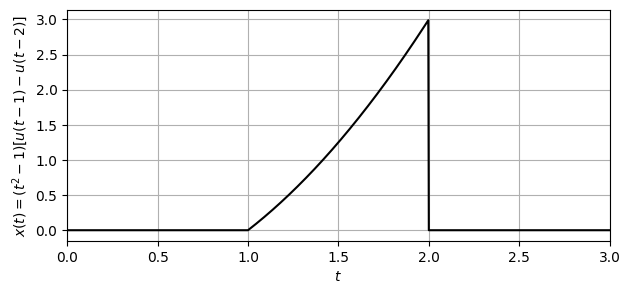

In [1]:
import numpy as np
import matplotlib.pyplot as plt

t1, t2 = 0, 3
points = 1000
t = np.linspace (t1, t2, points)

u1 = 1.0 * (t >= 1)
u2 = 1.0 * (t >= 2)
x = ((t**2) - 1) * (u1 - u2)

plt.figure (figsize = (7, 3))
plt.plot (t, x, "k")
plt.xlabel ("$t$")
plt.ylabel ("$x(t) = (t^{2} - 1) [u(t - 1) - u(t - 2)]$")
plt.xlim ([t1, t2])
plt.grid ()
plt.show ()

**(b)** Calcule, de forma analítica, a energia do sinal $x(t)$.

$ \boxed{E_{x} = \int_{-\infty}^{+\infty} x^{2}(t)dt} $

$
E_{x} = \int_{-\infty}^{+\infty} \{(t^{2} - 1)[u(t - 1) - u(t - 2)]\}^{2} dt \\
= \int_{1}^{2} (t^{2} − 1)^{2} dt \\
= \int_{1}^{2} (t^{4} - 2t^{2} + 1) dt \\
= \int_{1}^{2} t^{4} dt - 2 \int_{1}^{2} t^{2} dt + \int_{1}^{2} dt \\
= (\frac{t^{5}}{5}) \mid_{1}^{2} - 2 (\frac{t^{3}}{3}) \mid_{1}^{2} dt + (t) \mid_{1}^{2}
$

$ \boxed{E_{x} \approx 2.53333333333333} $

**(c)** Determine, de forma numérica, a energia do sinal $x(t)$. Compare com o resultado do item anterior.

In [2]:
dt = (t2 - t1) / points

print ("Energia (computacional) =", dt * np.sum (x**2))
print ("Energia (analítica)     =", 2.53333333333333)

Energia (computacional) = 2.51731801801531
Energia (analítica)     = 2.53333333333333


Entre os resultados obtidos pelo cálculo da forma analítica e pelo cálculo da forma numérica houve uma diferença de $0,0160153153$.

2. Considere o sinal $x(t)$ de tempo contínuo dado conforme a Figura 1 abaixo.

![figure-1.png](../docs/images/figure-1.png)

**(a)** Determine, de forma analítica, uma expressão matemática para o sinal $x(t)$ para todo $t$.

$
x(t) = \begin{cases}
2,                  & \quad -1.5 \leq t \leq 0 \\
2 e^{-\frac{t}{2}}, & \quad 0 \leq t \leq 3 \\
0,                  & \quad \text{caso contrário}
\end{cases}
$

$ \boxed{x(t) = (2)[u(t + 1.5) - u(t)] + (2e^{-\frac{t}{2}})[u(t) - u(t - 3)]} $

**(b)** Plote o sinal $x(t)$.

(-2.0, 4.0)

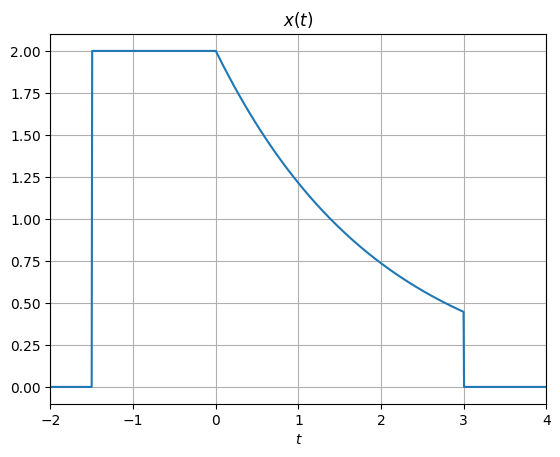

In [3]:
def u (t):
    return 1.0 * (t >= 0)

t1, t2 = -2, 4
t = np.linspace (t1, t2, points)

x1 = 2 * (u (t + 1.5) - u (t))
x2 = 2 * np.exp (-t/2) * (u (t) - u (t - 3))
x = x1 + x2

plt.figure ()
plt.plot (t, x)
plt.xlabel ("$t$")
plt.title("$x(t)$")
plt.grid ()
plt.xlim ([t1, t2])

**(c)** Plote os seguintes sinais:

- (i) $x(-t)$
- (ii) $x(t + 4)$
- (iii) $x(t - 2)$
- (iv) $x(2t)$
- (v) $x(\frac{t}{2})$

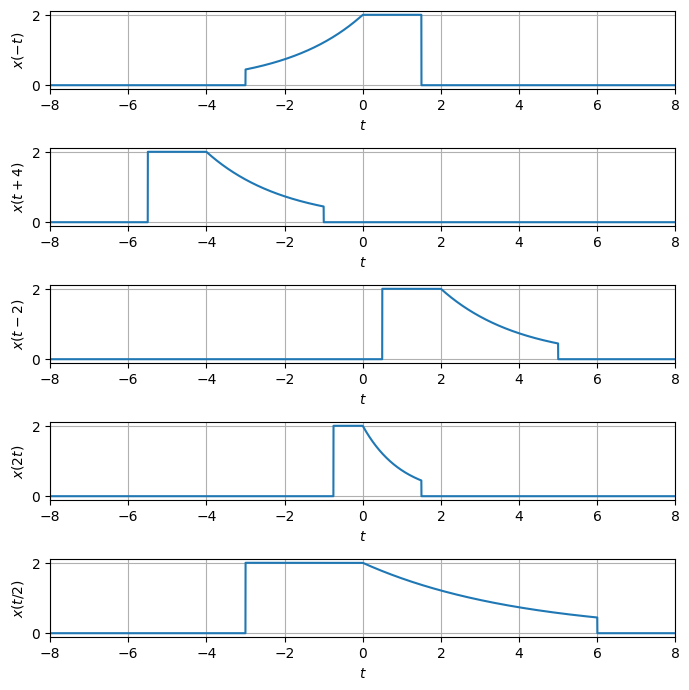

In [4]:
t1, t2 = -8, 8
points = 5000
t = np.linspace (t1, t2, points)

n = 1

def plot (time, label):
    global n

    x1 = 2 * (u (time + 1.5) - u (time))
    x2 = 2 * np.exp (-time / 2) * (u (time) - u (time - 3))
    x = x1 + x2

    plt.subplot (5, 1, n)
    plt.plot (t, x)
    plt.xlabel ("$t$")
    plt.ylabel (label)
    plt.grid ()
    plt.xlim ([t1, t2])

    n = n + 1

plt.figure (figsize = (7, 7))

plot (-t, "$x(-t)$")
plot (t + 4, "$x(t + 4)$")
plot (t - 2, "$x(t - 2)$")
plot (2 * t, "$x(2t)$")
plot (t / 2, "$x(t/2)$")

plt.tight_layout ()
plt.show ()

3. Um modulador em amplitude comercial é definido pela seguinte relação de entrada $x(t)$ e saída $y(t)$:\
$y(t) = (A + x(t))cos(2\pi f_{c}t)$\
Determine, de forma computacional, a saída para $0 \leq t \leq 0,1$ do sistema modulador em amplitude quando a entrada é igual à:\
$x(t) = cos(2\pi f_{m}t)$\
sendo $f_{m} = 50Hz$. Considere $A = 1,5$ e $f_{c} = 500Hz$. Plote a forma de onda do sinal de saída.

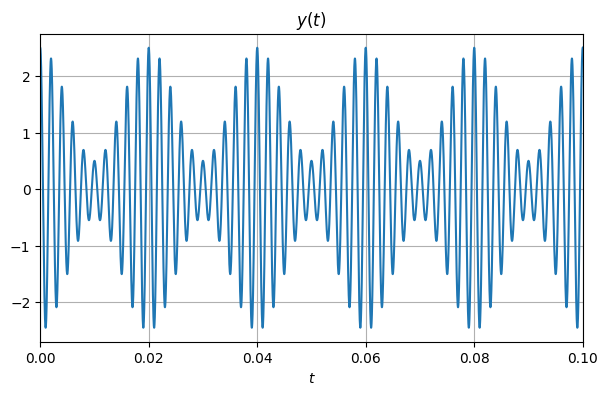

In [5]:
t1, t2 = 0, 0.1
points = 10_000

t = np.linspace (t1, t2, points)

f_m = 50
x = np.cos (2 * np.pi * f_m * t)

a = 1.5
f_c = 500
y = (a + x) * np.cos (2 * np.pi * f_c * t)

plt.figure (figsize = (7, 4))
plt.plot (t, y)
plt.xlabel ("$t$")
plt.title ("$y(t)$")
plt.grid ()
plt.xlim ([t1, t2])
plt.show ()

4. Um determinado sistema linear e invariante no tempo possui uma resposta ao impulso $h(t)$ dada por\
$h(t) = e^{-2t}u(t)$.

**(a)** Plote a resposta ao impulso do sistema para $0 \leq t \leq 3$.

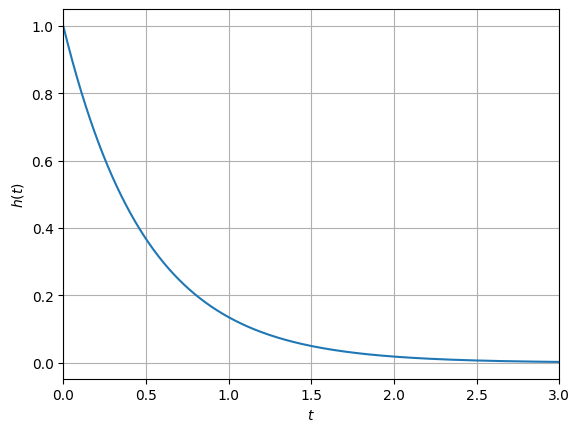

In [6]:
t1, t2 = 0, 3
points = 1000

t = np.linspace (t1, t2, points)

h = np.exp (-2 * t) * u (t)

plt.figure ()
plt.plot (t, h)
plt.xlabel ("$t$")
plt.ylabel ("$h(t)$")
plt.grid ()
plt.xlim ([t1, t2])
plt.show ()

**(b)** O sistema é estável? O sistema é causal? Justifique suas respostas.

$ \boxed{y(t) = \int_{-\infty}^{+\infty} x (\tau) h (t - \tau) d\tau}$

$
y(t) = \int_{-\infty}^{+\infty} x(\tau) e^{-2(t - \tau)} u (t - \tau) d\tau\\
= \int_{0}^{t} x (\tau) e^{-2t + 2 \tau} d\tau\\
= \int_{0}^{t} x (\tau) e^{-2t}e^{2 \tau} d\tau\\
= e^{-2t} \int_{0}^{t} x(\tau) e^{2 \tau} d\tau
$

O sistema é causal, pois em qualquer instante de tempo depende apenas da entrada nos instantes de tempo atual e passados. Como $h(t) = e^{-2t}u(t)$, o degrau unitário anula a resposta ao impulso para $t < 0$.

O sistema é estável, pois para qualquer sinal de entrada que tenha amplitude limitada, resulta em um sinal de saída com amplitude limitada ($\int_{0}^{t}e^{2 \tau}d \tau$ é integrável).

**(c)** Considere que o seguinte sinal:\
$x(t) = u(t) - u(t - 2)$\
é aplicado na entrada do sistema. Determine, de forma analítica, a expressão da saída $y(t)$ para todo $t$ utilizando o método gráfico da convolução.

$ \boxed {y(t) = e^{-2t} \int_{0}^{t} x(\tau) e^{2 \tau} d\tau} $

$ y(t) = e^{-2t} \int_{0}^{t} [u(\tau) - u(\tau - 2)] e^{2\tau} d\tau $

$
y(t) = e^{-2t} \int_{0}^{t} [u(\tau) e^{2\tau} - u(\tau - 2) e^{2\tau}] d\tau\\
= e^{-2t} [\int_{0}^{t} u(\tau) e^{2\tau} d\tau - \int_{0}^{t} u(\tau - 2) e^{2\tau} d\tau]\\
$

$ \boxed{y(t) = u(t) \frac{1 - e^{-2t}}{2} - u(t - 2) \frac{1 - e^{-2(t - 2)}}{2}} $

**(d)** Resolva o item (c) de forma numérica. Compare o resultado numérico com o resultado analítico, obtido no item (c). Uma forma de comparar consiste em plotar, em um mesmo gráfico, o sinal da saída obtido da forma analítica e o sinal de saída forma numérica.

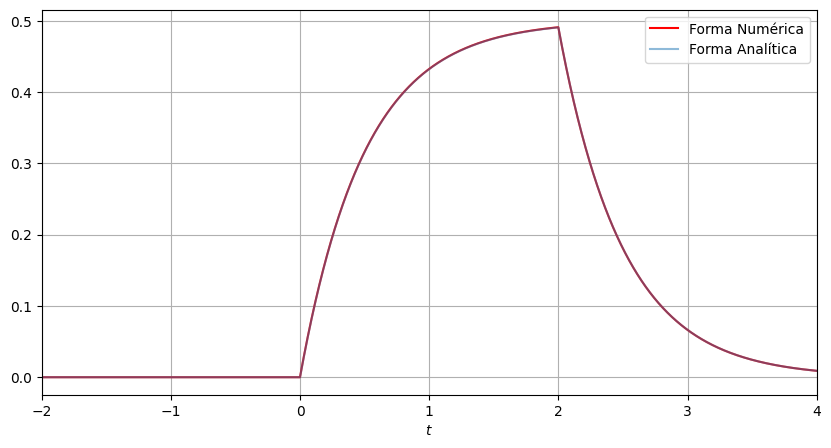

In [7]:
t1, t2 = -2, 4
points = 10_000
t = np.linspace (t1, t2, points)

x = u (t) - u (t - 2)
h = np.exp (-2 * t) * u (t)

dt = (t2 - t1) / points
y_num = dt * np.convolve (x, h)

t_num = np.linspace (2 * t1, 2 * t2, len (y_num))

y_ana = (u (t) * ((1 - np.exp (-2 * t)) / 2)) - (u (t - 2) * ((1 - np.exp (-2 * (t - 2))) / 2))

plt.figure (figsize = (10, 5))
plt.plot (t_num, y_num, 'r', label = "Forma Numérica")
plt.plot (t, y_ana, label = "Forma Analítica", alpha = 0.5)
plt.xlabel ("$t$")
plt.grid ()
plt.xlim ([t1, t2])
plt.legend (loc = "upper right")
plt.show ()

Os gráficos da formas numérica e analítica se sobrepõem completamente.

**(e)** Repetir os itens (a)-(d) quando a resposta ao impulso do sistema é igual à:

$h(t) = e^{t} u(t)$

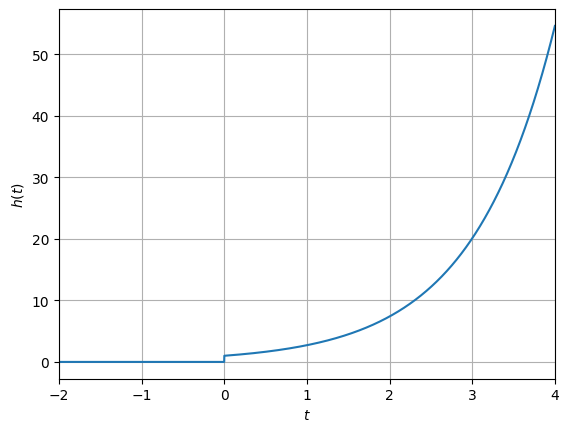

In [8]:
h = np.exp (t) * u (t)

plt.figure ()
plt.plot (t, h)
plt.xlabel ("$t$")
plt.ylabel ("$h(t)$")
plt.grid ()
plt.xlim ([t1, t2])
plt.show ()

$ \boxed{y(t) = \int_{-\infty}^{+\infty} x (\tau) h (t - \tau) d\tau}$

$
y(t) = \int_{-\infty}^{+\infty} x(\tau) e^{(t - \tau)} u (t - \tau) d\tau \\
= \int_{0}^{t} x (\tau) e^{t - \tau} d\tau\\
= \int_{0}^{t} x (\tau) e^{t}e^{-\tau} d\tau\\
= e^{t} \int_{0}^{t} x(\tau) e^{-\tau} d\tau
$

$ x(t) = u(t) - u(t - 2) $

$
y(t) = e^{t} \int_{0}^{t} [u(\tau) - u(\tau - 2)] e^{-\tau} d\tau \\
= e^{t} \int_{0}^{t} [u(\tau) e^{-\tau} - u(\tau - 2) e^{-\tau}] d\tau \\
= e^{t} [\int_{0}^{t} u(\tau) e^{-\tau} d\tau - \int_{2}^{t} u(\tau - 2) e^{-\tau} d\tau] \\
$

$
= e^{t} (\int_{0}^{t} e^{-\tau} d\tau - \int_{2}^{t} e^{-\tau}) d\tau \\
= e^{t} [u(t) (-e^{-\tau}) \mid_{0}^{t} - u(t - 2) (-e^{-\tau}) \mid_{2}^{t}] \\
= e^{t} [u(t) (-e^{-t} + e^{0}) - u(t - 2) (-e^{-t} + e^{-2})] \\
= e^{t} [u(t) (1 - e^{-t}) - u(t - 2) (e^{-2} - e^{-t})] \\
= e^{t} [u(t) - u(t) e^{-t} - u(t - 2) e^{-2} + u(t - 2) e^{-t}] \\
= e^{t} u(t) - u(t) e^{t} e^{-t} - u(t - 2) e^{t} e^{-2} + u(t - 2) e^{t} e^{-t} \\
= e^{t} u(t) - u(t) - u(t - 2) e^{t - 2} + u(t - 2)
$

$ \boxed{ y(t) = u(t) (e^{t}  - 1) - u(t - 2) (e^{t - 2} - 1) } $

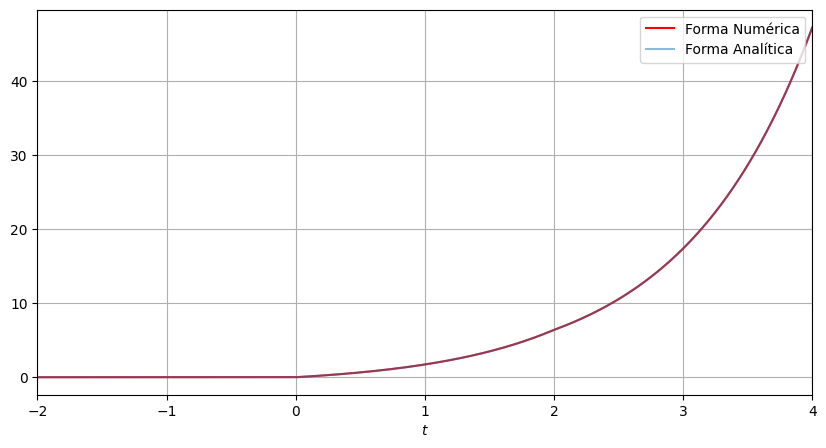

In [9]:
y_num = dt * np.convolve (x, h)

t_num = np.linspace (2 * t1, 2 * t2, len (y_num))

y_ana = (u (t) * (np.exp (t) - 1)) - (u (t - 2) * (np.exp (t - 2) - 1))

plt.figure (figsize = (10, 5))
plt.plot (t_num, y_num, 'r', label = "Forma Numérica")
plt.plot (t, y_ana, label = "Forma Analítica", alpha = 0.5)
plt.xlabel ("$t$")
plt.grid ()
plt.xlim ([t1, t2])
plt.legend (loc = "upper right")
plt.show ()


5. Um determinado circuito elétrico com tensão de entrada $v_{i}(t)$ e tensão de saída $v_{o}(t)$ é modelado através da seguinte equação diferencial ordinária:\
$\frac{d^{2} v_{o}(t)}{dt^{2}} + 7 \frac{d v_{o}(t)}{dt} + 10 v_{o}(t) = \frac{d v_{i}(t)}{dt} + 6 v_{i}(t)$\
As condições iniciais para esse circuito são $v_{o} = 6V$ e $\frac{d v_{o}}{dt} = -4 V/s$ e a entrada é $x(t) = 6 e^{-3t}u(t)$.

**(a)** Utilizando o método clássico, determine de forma analítica a saída do sistema $y(t)$ para todo $t$.

$
(D^{2} + 7 D + 10) v_{o}(t) = \frac{d v_{i}(t)}{dt} + 6 v_{i}(t) \\
Q(D) = D^{2} + 7 D + 10
$

Polinômio característico: $ Q(\lambda) = 0 $

$ D^{2} + 7 D + 10 = 0 $

$
\lambda = \frac{-7 \mp \sqrt{49 - 40}}{2} \\
= \frac{-7 \mp \sqrt{9}}{2} \\
= \frac{-7 \mp 3}{2}
$

$
\lambda_{1} = \frac{-7 + 3}{2} \\
= - \frac{4}{2}\\
= -2
$

$
\lambda_{2} = \frac{-7 - 3}{2} \\
= - \frac{10}{2}\\
= -5
$

Raízes reais e distintas: raízes $\{\lambda_{1}, \lambda_{2}, ..., \lambda_{N}\}$:

$ y_{n}(t) = C_{1} e^{\lambda_{1} t} + C_{2} e^{\lambda_{2} t} + ... + C_{N} e^{\lambda_{N} t} $

$
\lambda_{1} = -2 \\
\lambda_{2} = -5
$

$ \boxed{ y_{n}(t) = C_{1} e^{-2t} + C_{2} e^{-5t} } $

$
y_{f}''(t) + 7 y_{f}'(t) + 10 y_{f}(t) = \frac{d v_{i}(t)}{dt} + 6 v_{i}(t) \\
= \frac{d}{dt} [6 e^{-3 t} u(t)] + 6 (6 e^{-3 t} u(t))
$

$
=  6 \frac{d}{dt} [e^{-3 t} u(t)] + 6 (6 e^{-3 t} u(t)) \\
=  6 [-3 e^{-3 t} u(t) + e^{-3 t} \delta (t)] + 36 e^{-3 t} u(t) \\
=  6 [-3 e^{-3 t} u(t) + e^{0} \delta (t)] + 36 e^{-3 t} u(t) \\
=  -18 e^{-3 t} u(t) + 6 \delta (t) + 36 e^{-3 t} u(t) \\
=  18 e^{-3 t} u(t) + 6 \delta (t) \\
$

$ y_{f}''(t) + 7 y_{f}'(t) + 10 y_{f}(t) = 18 e^{-3 t}, t > 0 $

$ e^{\xi t}, \xi \neq \lambda_{i} (i = 1, 2, ..., N), \beta e^{\xi t} $

$ \boxed{ y_{f}(t) = \beta e^{-3 t}} $

$ y_{f}''(t) + 7 y_{f}'(t) + 10 y_{f}(t) = 18 e^{-3 t} $

$
(\beta e^{-3 t})'' + 7 (\beta e^{-3 t})' + 10 (\beta e^{-3 t}) = 18 e^{-3 t} \\
= \beta (-3 e^{-3 t})' + 7 \beta (-3 e^{-3 t}) + 10 \beta e^{-3 t} = 18 e^{-3 t} \\
= \beta (-3 e^{-3 t})' - 21 \beta  e^{-3 t} + 10 \beta e^{-3 t} = 18 e^{-3 t} \\
= -3 \beta (-3 e^{-3 t}) - 11 \beta  e^{-3 t} = 18 e^{-3 t} \\
= 9 \beta e^{-3 t} - 11 \beta  e^{-3 t} = 18 e^{-3 t} \\
= -2 \beta e^{-3 t} = 18 e^{-3 t} \\
= -2 \beta = 18 \\
\beta = -9
$

$ \boxed{ y_{f}(t) = -9 e^{-3 t}} $

$ y(t) = y_{n} + y_{f} $

$ \boxed{ y(t) = C_{1} e^{-2 t} + C_{2} e^{-5 t} - 9 e^{-3 t} } $

$
y(0) = C_{1} e^{0} + C_{2} e^{0} - 9 e^{0} = 6 \\
= C_{1} + C_{2} - 9 = 6 \\
C_{1} + C_{2} = 15
$

$
y'(t) = (C_{1} e^{-2 t} + C_{2} e^{-5 t} - 9 e^{-3 t})' \\
= C_{1} (e^{-2 t})' + C_{2} (e^{-5 t})' - 9 (e^{-3 t})' \\
= C_{1} (-2 e^{-2 t}) + C_{2} (-5 e^{-5 t}) - 9 (-3 e^{-3 t}) \\
= -2 C_{1}  e^{-2 t} - 5 C_{2} e^{-5 t} + 27 e^{-3 t} \\
$

$
y'(0) = -2 C_{1}  e^{0} - 5 C_{2} e^{0} + 27 e^{0} = -4 \\
= -2 C_{1} - 5 C_{2} + 27 = -4 \\
= -2 C_{1} - 5 C_{2} = -31 \\
$

$
\begin{cases}
C_{1} + C_{2} = 15 \\
-2 C_{1} - 5 C_{2} = -31
\end{cases}
$

$
C_{1} = \frac{44}{3} \\
C_{2} = \frac{1}{3} \\
$

$ \boxed{ y(t) = \frac{44}{3} e^{-2 t} + \frac{1}{3} e^{-5 t} - 9 e^{-3 t} } $

$ y(t) = \frac{44 e^{-2 t} + e^{-5 t}}{3} - \frac{27 e^{-3 t}}{3} $

$ \boxed{ y(t) = \frac{44 e^{-2 t} + e^{-5 t} - 27 e^{-3 t}}{3} } $


**(b)** Plote o sinal de saída para $0 \leq t \leq 2$.

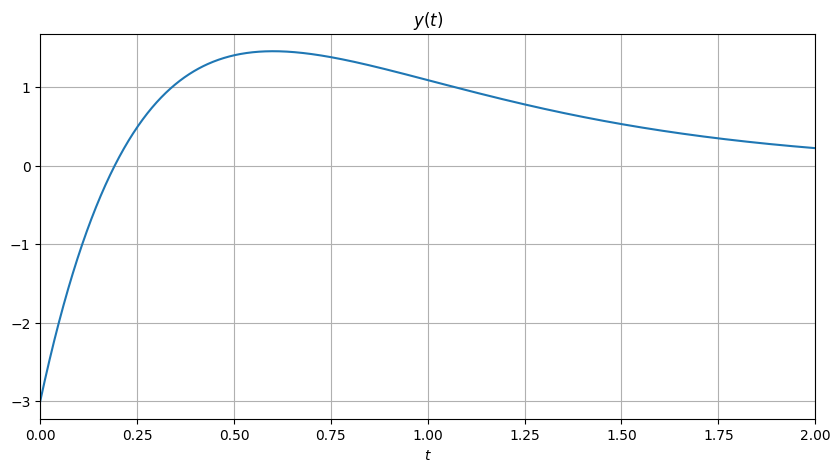

In [10]:
t1, t2 = 0, 2
points = 1000
t = np.linspace (t1, t2, points)

y_n = ((44 * np.exp (-2 * t)) + np.exp (-5 * t) - (27 * np.exp (-3 * t))) / 3
y_f = -9 * np.exp (-3 * t) * u (t)
y = y_f + y_n

plt.figure (figsize = (10, 5))
plt.plot (t, y)
plt.xlabel ("$t$")
plt.title ("$y(t)$")
plt.grid ()
plt.xlim ([t1, t2])
plt.show ()


**(c)** Utilizando computação simbólica, determine a expressão de saída para esse circuito quando a entrada é a mesma da apresentada no item (a). Verifique e compare seu resultado com aquele obtido no item (a).

In [11]:
import sympy as sp

sp.init_printing ()

t = sp.symbols ('t')
v_o = sp.Function ('v_o')
v_i = 6 * sp.exp (-3 * t)

y_n = sp.diff (v_o (t), t, t) + (7 * sp.diff (v_o (t), t)) + (10 * v_o (t))
y_f = sp.diff (v_i, t) + (6 * v_i)
y = sp.Eq (y_n, y_f)

initial_condition = {
    v_o (t).subs (t, 0):6,
    v_o (t).diff (t).subs (t, 0):-4
}

sp.dsolve (y, ics = initial_condition).expand ()

As equações obtidas pela forma analítica e pela forma numérica foram iguais.